# Cameroon Trade Partner Analysis: Bilateral Trade, Trade Balance and Partner Dynamics, 2015-2023

**Objective:** Analyze Cameroon's international trade relationships using annual bilateral trade
data from UN Comtrade, and identify the countries most important to Cameroon's trade.

**Note on scope:** The dataset actually supplied covers **2015-2023** (9 years), not 2015-2025.
2024 and 2025 are not yet available from UN Comtrade at the time this dataset was extracted.
All analysis below uses 2015-2023 as the study period; this is documented again in the
Limitations section.

**Priority countries analyzed individually:** China, Nigeria, France, Netherlands, Vietnam, India,
United States.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

RAW_PATH = '../data/raw/cameroon_total_trade_data.csv'
CLEAN_PATH = '../data/cleaned/cameroon_trade_cleaned.csv'
FIG_DIR = '../results/figures/'
TAB_DIR = '../results/tables/'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

STUDY_START, STUDY_END = 2015, 2023

PRIORITY_COUNTRIES = ['China', 'Nigeria', 'France', 'Netherlands', 'Viet Nam', 'India', 'USA']
PRIORITY_DISPLAY = {'Viet Nam': 'Vietnam', 'USA': 'United States'}


## Step 1. Data Understanding

In [2]:

# The raw CSV is a UN Comtrade export. Its data rows contain one more trailing
# comma than the header line, which makes pandas mis-align columns and silently
# push everything into the index unless index_col=False is set explicitly.
df_raw = pd.read_csv(RAW_PATH, encoding='latin1', index_col=False)

print("Shape (rows, columns):", df_raw.shape)
print()
print("Column names:")
print(df_raw.columns.tolist())


Shape (rows, columns): (2732, 47)

Column names:
['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO', 'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification', 'cmdCode', 'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']


In [3]:

print("Data types:\n")
print(df_raw.dtypes)


Data types:

typeCode                        str
freqCode                        str
refPeriodId                   int64
refYear                       int64
refMonth                      int64
period                        int64
reporterCode                  int64
reporterISO                     str
reporterDesc                    str
flowCode                        str
flowDesc                        str
partnerCode                   int64
partnerISO                      str
partnerDesc                     str
partner2Code                  int64
partner2ISO                     str
partner2Desc                    str
classificationCode              str
classificationSearchCode        str
isOriginalClassification       bool
cmdCode                         str
cmdDesc                         str
aggrLevel                     int64
isLeaf                         bool
customsCode                     str
customsDesc                     str
mosCode                       int64
motCode        

In [4]:

missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)


Columns with missing values:
qtyUnitAbbr       2732
altQtyUnitAbbr    2732
fobvalue          1449
cifvalue           978
netWgt             928
grossWgt           923
altQty             599
qty                599
dtype: int64


In [5]:

print("Duplicate full rows:", df_raw.duplicated().sum())
print("Unique years:", sorted(df_raw['refYear'].unique()))
print("Unique trade flows:", df_raw['flowDesc'].unique())
print("Number of unique partners (incl. World):", df_raw['partnerDesc'].nunique())
print("Reporter(s):", df_raw['reporterDesc'].unique())
print("Second partner (should be World only):", df_raw['partner2Desc'].unique())
print()
print("Min primaryValue:", df_raw['primaryValue'].min())
print("Max primaryValue:", df_raw['primaryValue'].max())


Duplicate full rows: 0
Unique years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Unique trade flows: <StringArray>
['Import', 'Export']
Length: 2, dtype: str
Number of unique partners (incl. World): 232
Reporter(s): <StringArray>
['Cameroon']
Length: 1, dtype: str
Second partner (should be World only): <StringArray>
['World']
Length: 1, dtype: str

Min primaryValue: 2.0
Max primaryValue: 8296875048.587


In [6]:

df_raw[['refYear','flowDesc','partnerDesc','reporterDesc','partner2Desc','primaryValue']].sample(10, random_state=1)


,refYear,flowDesc,partnerDesc,reporterDesc,partner2Desc,primaryValue
1089,2018,Import,Turkmenistan,Cameroon,World,"634,784"
292,2015,Export,Uganda,Cameroon,World,"201,841"
297,2015,Export,Burkina Faso,Cameroon,World,"3,702,279"
1299,2019,Import,Honduras,Cameroon,World,"6,416"
877,2017,Export,Mozambique,Cameroon,World,"27,727"
1832,2020,Export,Burkina Faso,Cameroon,World,"831,515"
2731,2023,Export,"Areas, nes",Cameroon,World,"98,688"
791,2017,Import,United Kingdom,Cameroon,World,"60,460,748"
2607,2023,Export,Australia,Cameroon,World,"73,387"
654,2017,Import,Equatorial Guinea,Cameroon,World,"23,563,442"


**Meaning of the key columns used in this analysis:**

- `refYear` – calendar year of the trade record.
- `flowDesc` – direction of trade: `Import` (goods entering Cameroon) or `Export` (goods leaving Cameroon).
- `reporterDesc` – the country submitting the data to UN Comtrade; should always be Cameroon.
- `partnerDesc` – the trading partner country (or `World`, the aggregate of all partners).
- `partner2Desc` – a secondary partner dimension used by Comtrade for re-export tracking; here it is fixed to `World` for every row, meaning no re-export splitting is present in this extract.
- `cmdDesc` / `cmdCode` – product classification; fixed to `TOTAL` / `All Commodities` in this extract, i.e. the data is not broken down by product.
- `primaryValue` – the trade value in current US dollars, and the field used throughout this analysis.
- `fobvalue` / `cifvalue` – Free-On-Board and Cost-Insurance-Freight value variants; not used because `primaryValue` is Comtrade's standard, most-complete value field (see Step 2).


## Step 2. Data Cleaning

In [7]:

df = df_raw.copy()

# --- Standardize column names (snake_case, only the ones we use) ---
df = df.rename(columns={
    'refYear': 'year',
    'flowDesc': 'trade_flow',
    'reporterDesc': 'reporter',
    'partnerDesc': 'partner',
    'partner2Desc': 'partner2',
    'primaryValue': 'trade_value_usd',
})

# --- Convert year to integer, trade value to numeric ---
df['year'] = df['year'].astype(int)
df['trade_value_usd'] = pd.to_numeric(df['trade_value_usd'], errors='coerce')

print("Rows where trade_value_usd failed to convert to numeric:", df['trade_value_usd'].isna().sum())


Rows where trade_value_usd failed to convert to numeric: 0


In [8]:

# --- Confirm reporter is always Cameroon ---
print("Reporter values:", df['reporter'].unique())
assert (df['reporter'] == 'Cameroon').all(), "Non-Cameroon reporter rows found"

# --- Confirm partner2 (second partner) is always World ---
print("Partner2 values:", df['partner2'].unique())
assert (df['partner2'] == 'World').all(), "Non-World second-partner rows found"

# --- Confirm both Import and Export flows are present ---
print("Trade flow values:", df['trade_flow'].unique())
assert set(df['trade_flow'].unique()) == {'Import', 'Export'}


Reporter values: <StringArray>
['Cameroon']
Length: 1, dtype: str
Partner2 values: <StringArray>
['World']
Length: 1, dtype: str
Trade flow values: <StringArray>
['Import', 'Export']
Length: 2, dtype: str


In [9]:

# --- Duplicate check on the business key (year, flow, partner) ---
dupe_key = df.duplicated(subset=['year', 'trade_flow', 'partner']).sum()
print("Duplicate (year, trade_flow, partner) combinations:", dupe_key)
print("Duplicate full rows:", df.duplicated().sum())
# None found -> no rows dropped for duplication.


Duplicate (year, trade_flow, partner) combinations: 0
Duplicate full rows: 0


In [10]:

# --- Zero values ---
zero_vals = (df['trade_value_usd'] == 0).sum()
print("Rows with trade_value_usd == 0:", zero_vals)

# --- Abnormal / negative values ---
neg_vals = (df['trade_value_usd'] < 0).sum()
print("Rows with negative trade_value_usd:", neg_vals)

# --- Missing trade values ---
missing_vals = df['trade_value_usd'].isna().sum()
print("Rows with missing trade_value_usd:", missing_vals)
if missing_vals > 0:
    display_cols = ['year','trade_flow','partner','trade_value_usd']
    print(df[df['trade_value_usd'].isna()][display_cols])


Rows with trade_value_usd == 0: 0
Rows with negative trade_value_usd: 0
Rows with missing trade_value_usd: 0


In [11]:

# Decision: rows with missing trade_value_usd carry no usable information for
# any calculation in this project (they cannot be summed, ranked, or charted),
# so they are dropped. All other rows are retained, including the 'World'
# aggregate row per year/flow, which is kept separately as a reconciliation
# total rather than mixed into partner-level rankings (see Step 4).
before = len(df)
df = df.dropna(subset=['trade_value_usd']).copy()
after = len(df)
print(f"Dropped {before - after} row(s) with missing trade values (out of {before}).")


Dropped 0 row(s) with missing trade values (out of 2732).


In [12]:

# --- Standardize a couple of partner names for readability in charts/tables ---
NAME_FIX = {'Viet Nam': 'Vietnam', 'USA': 'United States'}
df['partner'] = df['partner'].replace(NAME_FIX)
PRIORITY = [NAME_FIX.get(c, c) for c in PRIORITY_COUNTRIES]

# Keep only the study window actually present in the data
df = df[(df['year'] >= STUDY_START) & (df['year'] <= STUDY_END)].copy()

# Separate the World aggregate rows (partner == 'World') from bilateral partner rows
world_totals = df[df['partner'] == 'World'].copy()
bilateral = df[df['partner'] != 'World'].copy()

print("Bilateral partner-level rows:", len(bilateral))
print("World aggregate rows (used for reconciliation only):", len(world_totals))
print("Unique bilateral partners:", bilateral['partner'].nunique())


Bilateral partner-level rows: 2714
World aggregate rows (used for reconciliation only): 18
Unique bilateral partners: 231


In [13]:

# Keep only the columns needed going forward and save the cleaned dataset
clean_cols = ['year', 'trade_flow', 'partner', 'trade_value_usd']
df_clean = bilateral[clean_cols].sort_values(['year', 'trade_flow', 'partner']).reset_index(drop=True)
df_clean.to_csv(CLEAN_PATH, index=False)
df_clean.head()


,year,trade_flow,partner,trade_value_usd
0,2015,Export,Albania,"104,943"
1,2015,Export,Algeria,"5,405,850"
2,2015,Export,Andorra,"15,173"
3,2015,Export,Angola,"1,162,278"
4,2015,Export,Antigua and Barbuda,"120,244"


## Step 3. Cameroon's Overall Trade

In [14]:

overall = world_totals.pivot_table(index='year', columns='trade_flow', values='trade_value_usd', aggfunc='sum')
overall = overall.rename(columns={'Export': 'exports', 'Import': 'imports'})
overall['total_trade'] = overall['exports'] + overall['imports']
overall['trade_balance'] = overall['exports'] - overall['imports']

overall['export_growth_pct'] = overall['exports'].pct_change() * 100
overall['import_growth_pct'] = overall['imports'].pct_change() * 100
overall['total_trade_growth_pct'] = overall['total_trade'].pct_change() * 100

overall_display = overall.copy()
overall_display.to_csv(TAB_DIR + 'overall_trade_by_year.csv')
overall_display.round(2)


trade_flow,exports,imports,total_trade,trade_balance,export_growth_pct,import_growth_pct,total_trade_growth_pct
year,,,,,,,
2015,"4,052,643,290","6,036,814,820","10,089,458,110","-1,984,171,530",NaN,NaN,NaN
2016,"2,130,449,501","4,898,887,030","7,029,336,531","-2,768,437,529",-47,-19,-30
2017,"3,264,185,172","5,183,629,302","8,447,814,474","-1,919,444,131",53,6,20
2018,"3,804,792,059","6,133,556,703","9,938,348,762","-2,328,764,644",17,18,18
2019,"4,076,568,061","6,561,572,964","10,638,141,025","-2,485,004,903",7,7,7
2020,"3,152,853,063","5,610,413,589","8,763,266,652","-2,457,560,526",-23,-14,-18
2021,"4,294,055,976","6,966,293,017","11,260,348,993","-2,672,237,040",36,24,28
2022,"5,622,985,686","7,926,780,025","13,549,765,712","-2,303,794,339",31,14,20
2023,"4,967,511,896","8,296,875,049","13,264,386,945","-3,329,363,153",-12,5,-2


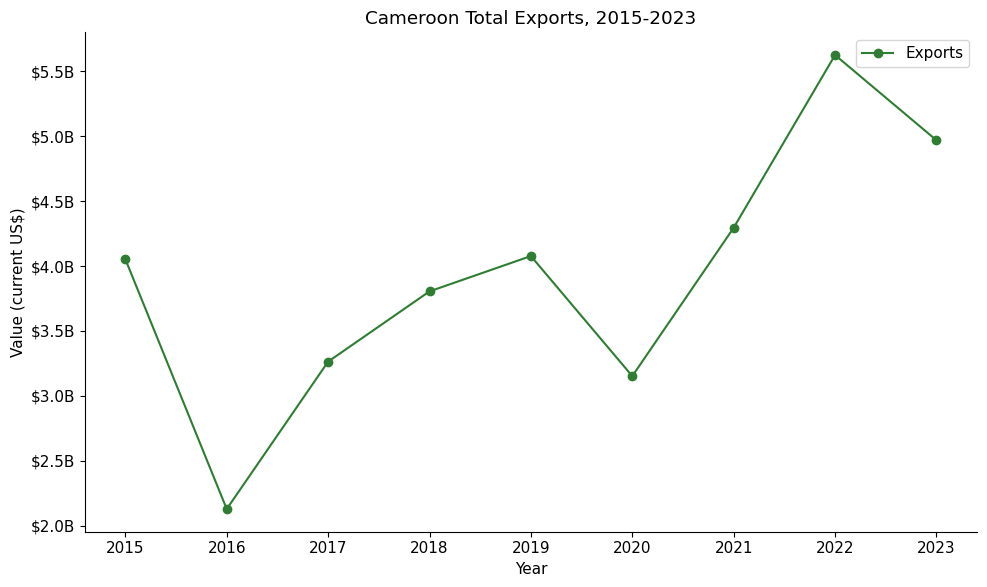

In [15]:

def fmt_billions(x, pos):
    return f'${x/1e9:,.1f}B'

fig, ax = plt.subplots()
ax.plot(overall.index, overall['exports'], marker='o', color='#2E7D32', label='Exports')
ax.set_title("Cameroon Total Exports, 2015-2023")
ax.set_xlabel('Year'); ax.set_ylabel('Value (current US$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '01_total_exports.png', dpi=150)
plt.show()


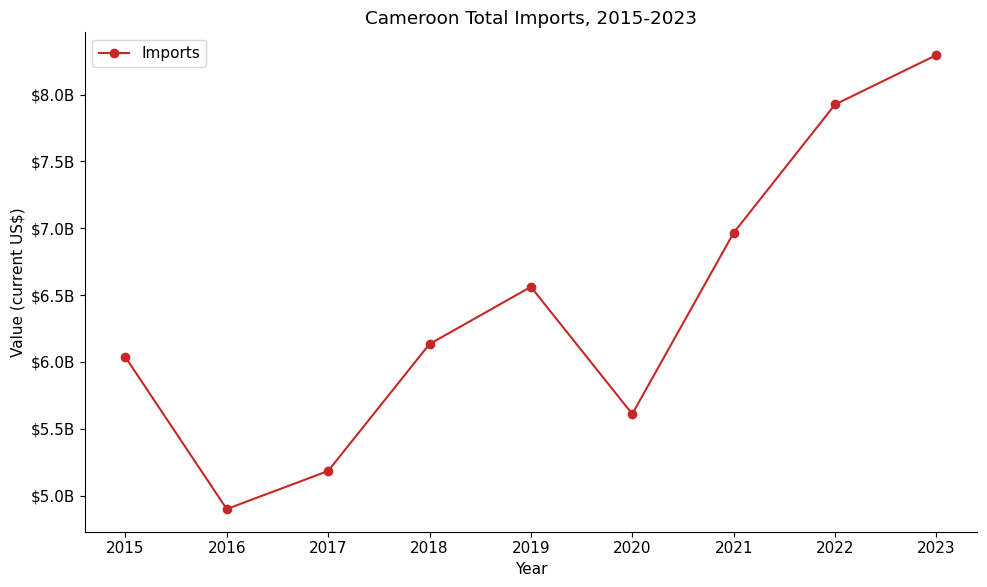

In [16]:

fig, ax = plt.subplots()
ax.plot(overall.index, overall['imports'], marker='o', color='#C62828', label='Imports')
ax.set_title("Cameroon Total Imports, 2015-2023")
ax.set_xlabel('Year'); ax.set_ylabel('Value (current US$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '02_total_imports.png', dpi=150)
plt.show()


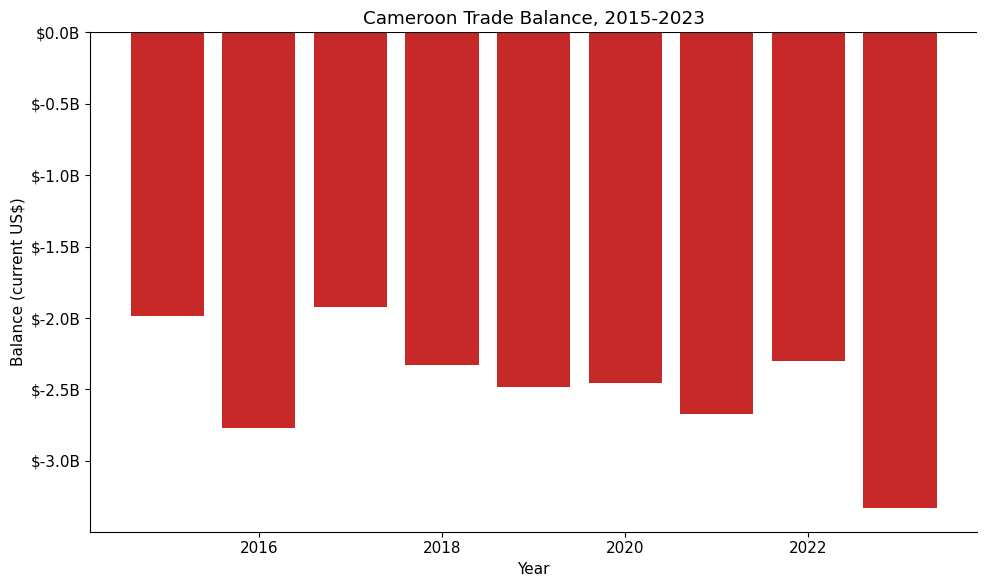

In [17]:

fig, ax = plt.subplots()
colors = ['#C62828' if v < 0 else '#2E7D32' for v in overall['trade_balance']]
ax.bar(overall.index, overall['trade_balance'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Cameroon Trade Balance, 2015-2023")
ax.set_xlabel('Year'); ax.set_ylabel('Balance (current US$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
plt.tight_layout()
plt.savefig(FIG_DIR + '03_trade_balance.png', dpi=150)
plt.show()


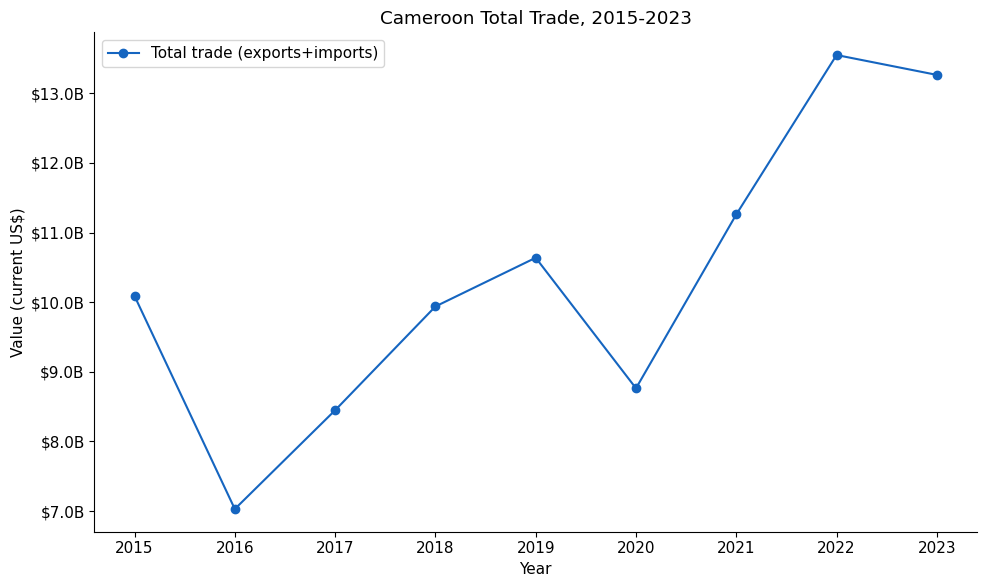

In [18]:

fig, ax = plt.subplots()
ax.plot(overall.index, overall['total_trade'], marker='o', color='#1565C0', label='Total trade (exports+imports)')
ax.set_title("Cameroon Total Trade, 2015-2023")
ax.set_xlabel('Year'); ax.set_ylabel('Value (current US$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '04_total_trade.png', dpi=150)
plt.show()


In [19]:

print("Overall trade position, 2015 vs 2023:")
print(f"Exports:      {overall.loc[2015,'exports']:,.0f} -> {overall.loc[2023,'exports']:,.0f} USD")
print(f"Imports:      {overall.loc[2015,'imports']:,.0f} -> {overall.loc[2023,'imports']:,.0f} USD")
print(f"Trade balance:{overall.loc[2015,'trade_balance']:,.0f} -> {overall.loc[2023,'trade_balance']:,.0f} USD")
print(f"Cameroon ran a trade deficit (imports > exports) in {(overall['trade_balance']<0).sum()} of {len(overall)} years.")


Overall trade position, 2015 vs 2023:
Exports:      4,052,643,290 -> 4,967,511,896 USD
Imports:      6,036,814,820 -> 8,296,875,049 USD
Trade balance:-1,984,171,530 -> -3,329,363,153 USD
Cameroon ran a trade deficit (imports > exports) in 9 of 9 years.


## Step 4. Rank Cameroon's Trading Partners

In [20]:

partner_flow = df_clean.groupby(['partner', 'trade_flow'])['trade_value_usd'].sum().unstack(fill_value=0)
partner_flow = partner_flow.rename(columns={'Export': 'total_exports', 'Import': 'total_imports'})
for col in ['total_exports', 'total_imports']:
    if col not in partner_flow.columns:
        partner_flow[col] = 0
partner_flow['total_bilateral_trade'] = partner_flow['total_exports'] + partner_flow['total_imports']

grand_total_trade = partner_flow['total_bilateral_trade'].sum()
partner_flow['pct_share_total_trade'] = partner_flow['total_bilateral_trade'] / grand_total_trade * 100

ranked_partners = partner_flow.sort_values('total_bilateral_trade', ascending=False)
ranked_partners.to_csv(TAB_DIR + 'top_trading_partners.csv')

top5 = ranked_partners.head(5)
top10 = ranked_partners.head(10)
print("Top 5 partners by total bilateral trade:")
print(top5[['total_bilateral_trade','pct_share_total_trade']].round(1))
print()
print(f"Top 5 combined share of total trade: {top5['pct_share_total_trade'].sum():.1f}%")
print(f"Top 10 combined share of total trade: {top10['pct_share_total_trade'].sum():.1f}%")


Top 5 partners by total bilateral trade:
trade_flow   total_bilateral_trade  pct_share_total_trade
partner                                                  
China               15,504,136,224                     17
France               7,678,009,141                      8
Netherlands          7,458,029,195                      8
India                6,939,375,863                      8
Italy                4,335,483,929                      5

Top 5 combined share of total trade: 45.1%
Top 10 combined share of total trade: 61.5%


In [21]:

top_export_dest = ranked_partners.sort_values('total_exports', ascending=False)[['total_exports']].head(15)
top_export_dest['pct_share_exports'] = top_export_dest['total_exports'] / partner_flow['total_exports'].sum() * 100
top_export_dest.to_csv(TAB_DIR + 'top_export_destinations.csv')

top_import_src = ranked_partners.sort_values('total_imports', ascending=False)[['total_imports']].head(15)
top_import_src['pct_share_imports'] = top_import_src['total_imports'] / partner_flow['total_imports'].sum() * 100
top_import_src.to_csv(TAB_DIR + 'top_import_sources.csv')

print("Top 10 export destinations:")
print(top_export_dest.head(10).round(1))


Top 10 export destinations:
trade_flow     total_exports  pct_share_exports
partner                                        
Netherlands    5,807,682,624                 16
China          5,203,656,959                 15
India          3,355,625,487                 10
Italy          3,009,489,371                  8
France         2,531,021,688                  7
Spain          2,203,986,300                  6
Belgium        1,452,753,094                  4
Chad           1,192,439,569                  3
Bangladesh     1,157,974,060                  3
United States    983,847,368                  3


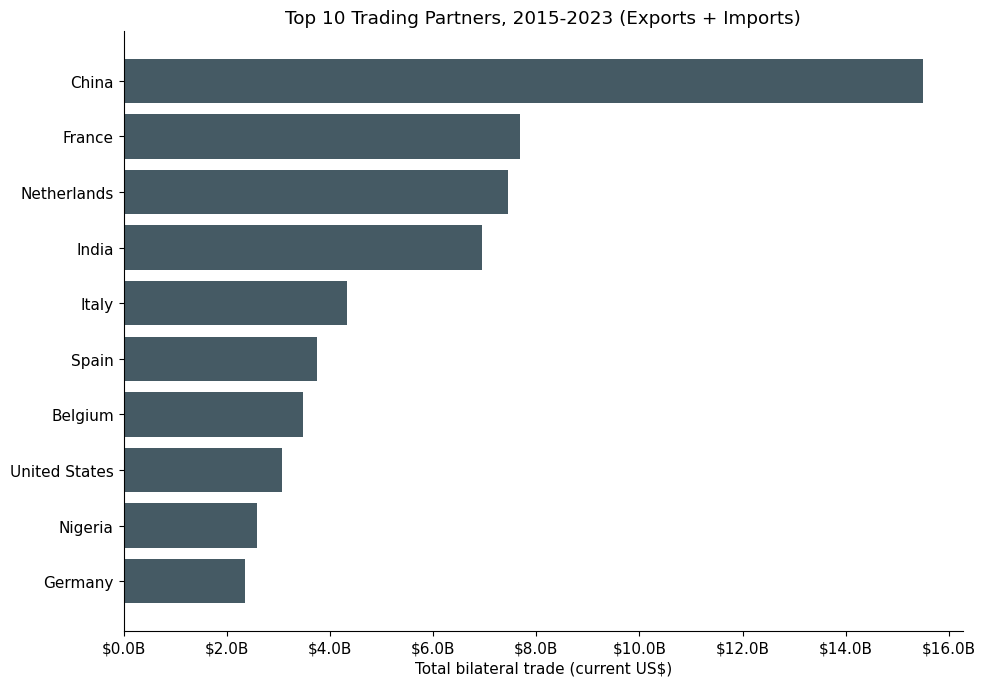

In [22]:

fig, ax = plt.subplots(figsize=(10,7))
data = top10.sort_values('total_bilateral_trade')
ax.barh(data.index, data['total_bilateral_trade'], color='#455A64')
ax.set_title('Top 10 Trading Partners, 2015-2023 (Exports + Imports)')
ax.set_xlabel('Total bilateral trade (current US$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
plt.tight_layout()
plt.savefig(FIG_DIR + '05_top10_trading_partners.png', dpi=150)
plt.show()


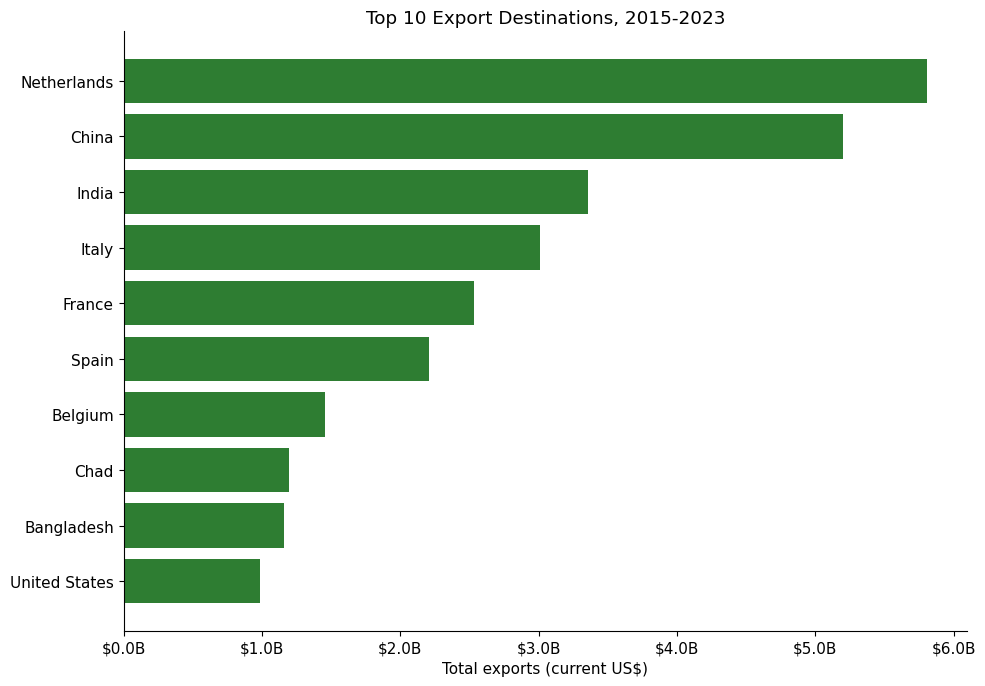

In [23]:

fig, ax = plt.subplots(figsize=(10,7))
data = top_export_dest.head(10).sort_values('total_exports')
ax.barh(data.index, data['total_exports'], color='#2E7D32')
ax.set_title('Top 10 Export Destinations, 2015-2023')
ax.set_xlabel('Total exports (current US$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
plt.tight_layout()
plt.savefig(FIG_DIR + '06_top10_export_destinations.png', dpi=150)
plt.show()


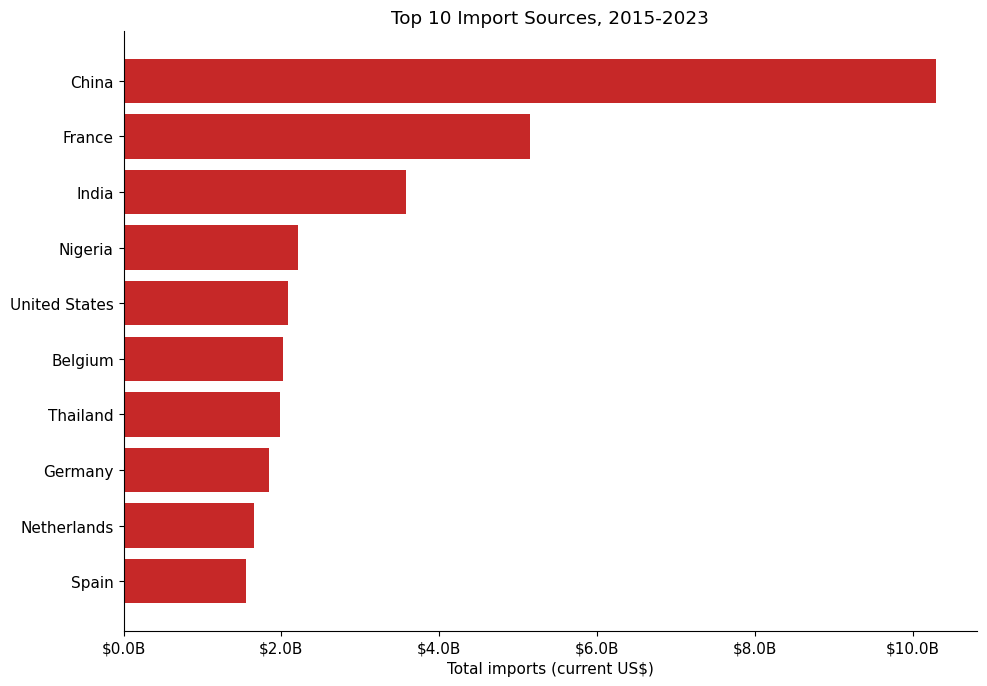

In [24]:

fig, ax = plt.subplots(figsize=(10,7))
data = top_import_src.head(10).sort_values('total_imports')
ax.barh(data.index, data['total_imports'], color='#C62828')
ax.set_title('Top 10 Import Sources, 2015-2023')
ax.set_xlabel('Total imports (current US$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
plt.tight_layout()
plt.savefig(FIG_DIR + '07_top10_import_sources.png', dpi=150)
plt.show()


## Step 5. Export Partner Analysis

In [25]:

exports_pivot = df_clean[df_clean['trade_flow']=='Export'].pivot_table(
    index='partner', columns='year', values='trade_value_usd', aggfunc='sum').fillna(0)

exp_2015 = exports_pivot.get(2015, pd.Series(0, index=exports_pivot.index))
exp_2023 = exports_pivot.get(2023, pd.Series(0, index=exports_pivot.index))
exp_growth = pd.DataFrame({
    'export_2015': exp_2015,
    'export_2023': exp_2023,
})
exp_growth['abs_change'] = exp_growth['export_2023'] - exp_growth['export_2015']
exp_growth['pct_change'] = np.where(exp_growth['export_2015']>0,
                                     exp_growth['abs_change']/exp_growth['export_2015']*100, np.nan)
exp_growth = exp_growth.join(partner_flow[['total_exports']])

print("Fastest-growing export destinations (min $100k in 2015, ranked by % change):")
print(exp_growth[exp_growth['export_2015']>=1e5].sort_values('pct_change', ascending=False).head(10).round(1))
print()
print("Declining export destinations (min $100k in 2015, ranked by % change):")
print(exp_growth[exp_growth['export_2015']>=1e5].sort_values('pct_change').head(10).round(1))
print()
emerging_exports = exp_growth[(exp_growth['export_2015']==0) & (exp_growth['export_2023']>0)].sort_values('export_2023', ascending=False)
print("Emerging export destinations (zero in 2015, positive in 2023):")
print(emerging_exports.head(10).round(1))


Fastest-growing export destinations (min $100k in 2015, ranked by % change):
           export_2015  export_2023  abs_change  pct_change  total_exports
partner                                                                   
Ethiopia       337,531   15,122,129  14,784,598       4,380     15,552,643
Mexico         147,041    2,296,636   2,149,595       1,462     15,527,336
Estonia        172,969    2,546,489   2,373,520       1,372      3,714,433
Indonesia   20,430,089  193,697,633 173,267,544         848    536,199,587
Albania        104,943      755,361     650,418         620      2,489,556
Türkiye     20,596,228  146,652,096 126,055,868         612    425,566,902
Uganda         201,841      843,923     642,082         318      1,683,666
Germany     35,932,570  131,866,164  95,933,594         267    510,304,417
Pakistan     1,430,635    4,911,602   3,480,967         243     59,456,884
Romania        168,509      547,045     378,536         225      9,911,031

Declining export desti

In [26]:

rows = []
years = list(range(STUDY_START, STUDY_END+1))
for c in PRIORITY:
    series = exports_pivot.loc[c] if c in exports_pivot.index else pd.Series(0, index=years)
    total = series.sum()
    avg = series.mean()
    v2015 = series.get(2015, 0)
    v2023 = series.get(2023, 0)
    growth = (v2023 - v2015) / v2015 * 100 if v2015 > 0 else np.nan
    share = total / partner_flow['total_exports'].sum() * 100
    rows.append([c, total, avg, share, v2015, v2023, growth])

priority_exports = pd.DataFrame(rows, columns=['country','total_exports','avg_annual_exports',
    'export_share_pct','export_2015','export_2023','export_growth_pct']).set_index('country')
priority_exports.to_csv(TAB_DIR + 'priority_country_export_profile.csv')
priority_exports.round(1)


,total_exports,avg_annual_exports,export_share_pct,export_2015,export_2023,export_growth_pct
country,,,,,,
China,"5,203,656,959","578,184,107",15,"506,026,663","385,441,913",-24
Nigeria,"378,779,330","42,086,592",1,"42,362,990","65,644,591",55
France,"2,531,021,688","281,224,632",7,"208,922,029","615,012,972",194
Netherlands,"5,807,682,624","645,298,069",16,"659,765,948","1,152,959,358",75
Vietnam,"825,161,574","91,684,619",2,"89,042,444","57,698,644",-35
India,"3,355,625,487","372,847,276",10,"632,743,481","475,507,176",-25
United States,"983,847,368","109,316,374",3,"83,164,028","53,353,869",-36


## Step 6. Import Partner Analysis

In [27]:

imports_pivot = df_clean[df_clean['trade_flow']=='Import'].pivot_table(
    index='partner', columns='year', values='trade_value_usd', aggfunc='sum').fillna(0)

imp_2015 = imports_pivot.get(2015, pd.Series(0, index=imports_pivot.index))
imp_2023 = imports_pivot.get(2023, pd.Series(0, index=imports_pivot.index))
imp_growth = pd.DataFrame({'import_2015': imp_2015, 'import_2023': imp_2023})
imp_growth['abs_change'] = imp_growth['import_2023'] - imp_growth['import_2015']
imp_growth['pct_change'] = np.where(imp_growth['import_2015']>0,
                                     imp_growth['abs_change']/imp_growth['import_2015']*100, np.nan)
imp_growth = imp_growth.join(partner_flow[['total_imports']])

print("Fastest-growing import sources (min $100k in 2015, ranked by % change):")
print(imp_growth[imp_growth['import_2015']>=1e5].sort_values('pct_change', ascending=False).head(10).round(1))
print()
print("Declining import sources (min $100k in 2015, ranked by % change):")
print(imp_growth[imp_growth['import_2015']>=1e5].sort_values('pct_change').head(10).round(1))


Fastest-growing import sources (min $100k in 2015, ranked by % change):
                      import_2015  import_2023  abs_change  pct_change  \
partner                                                                  
Peru                      152,631   24,014,178  23,861,547      15,634   
Kuwait                    357,636   26,877,747  26,520,111       7,415   
Gabon                   1,055,584   57,560,738  56,505,154       5,353   
Chad                      274,313   13,036,230  12,761,917       4,652   
Lithuania                 653,787   23,726,383  23,072,596       3,529   
Latvia                    779,966   13,239,271  12,459,305       1,597   
Norway                 12,794,843  188,077,224 175,282,381       1,370   
Algeria                 1,547,959   21,916,656  20,368,697       1,316   
Saudi Arabia           11,106,527  117,251,214 106,144,687         956   
Central African Rep.      105,347    1,072,538     967,191         918   

                      total_imports  
p

In [28]:

rows = []
for c in PRIORITY:
    series = imports_pivot.loc[c] if c in imports_pivot.index else pd.Series(0, index=years)
    total = series.sum()
    avg = series.mean()
    v2015 = series.get(2015, 0)
    v2023 = series.get(2023, 0)
    growth = (v2023 - v2015) / v2015 * 100 if v2015 > 0 else np.nan
    share = total / partner_flow['total_imports'].sum() * 100
    rows.append([c, total, avg, share, v2015, v2023, growth])

priority_imports = pd.DataFrame(rows, columns=['country','total_imports','avg_annual_imports',
    'import_share_pct','import_2015','import_2023','import_growth_pct']).set_index('country')
priority_imports.to_csv(TAB_DIR + 'priority_country_import_profile.csv')
priority_imports.round(1)


,total_imports,avg_annual_imports,import_share_pct,import_2015,import_2023,import_growth_pct
country,,,,,,
China,"10,300,479,264","1,144,497,696",18,"1,172,904,261","1,572,718,974",34
Nigeria,"2,208,912,707","245,434,745",4,"731,736,125","65,500,884",-91
France,"5,146,987,453","571,887,495",9,"619,771,328","632,408,639",2
Netherlands,"1,650,346,571","183,371,841",3,"102,176,978","159,767,631",56
Vietnam,"212,621,187","23,624,576",0,"38,151,903","20,728,950",-46
India,"3,583,750,376","398,194,486",6,"217,884,157","959,886,844",340
United States,"2,086,719,737","231,857,748",4,"225,461,481","400,945,573",78


## Step 7. Bilateral Trade Analysis (Priority Countries)

In [29]:

bilateral_summary = pd.DataFrame({
    'exports': priority_exports['total_exports'],
    'imports': priority_imports['total_imports'],
})
bilateral_summary['total_bilateral_trade'] = bilateral_summary['exports'] + bilateral_summary['imports']
bilateral_summary['trade_balance'] = bilateral_summary['exports'] - bilateral_summary['imports']
bilateral_summary['share_of_total_trade_pct'] = bilateral_summary['total_bilateral_trade'] / grand_total_trade * 100
bilateral_summary = bilateral_summary.sort_values('total_bilateral_trade', ascending=False)
bilateral_summary.to_csv(TAB_DIR + 'priority_partner_bilateral_summary.csv')
bilateral_summary.round(1)


,exports,imports,total_bilateral_trade,trade_balance,share_of_total_trade_pct
country,,,,,
China,"5,203,656,959","10,300,479,264","15,504,136,224","-5,096,822,305",17
France,"2,531,021,688","5,146,987,453","7,678,009,141","-2,615,965,764",8
Netherlands,"5,807,682,624","1,650,346,571","7,458,029,195","4,157,336,053",8
India,"3,355,625,487","3,583,750,376","6,939,375,863","-228,124,889",8
United States,"983,847,368","2,086,719,737","3,070,567,105","-1,102,872,369",3
Nigeria,"378,779,330","2,208,912,707","2,587,692,037","-1,830,133,376",3
Vietnam,"825,161,574","212,621,187","1,037,782,762","612,540,387",1


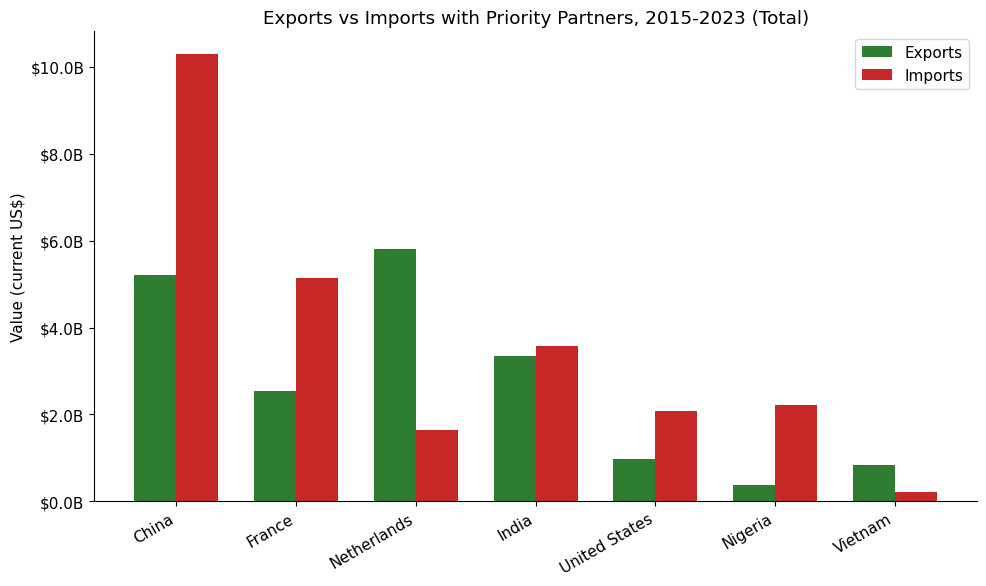

In [30]:

fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(bilateral_summary))
width = 0.35
ax.bar(x - width/2, bilateral_summary['exports'], width, label='Exports', color='#2E7D32')
ax.bar(x + width/2, bilateral_summary['imports'], width, label='Imports', color='#C62828')
ax.set_xticks(x); ax.set_xticklabels(bilateral_summary.index, rotation=30, ha='right')
ax.set_title('Exports vs Imports with Priority Partners, 2015-2023 (Total)')
ax.set_ylabel('Value (current US$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '09_priority_partner_trade_share.png', dpi=150)
plt.show()


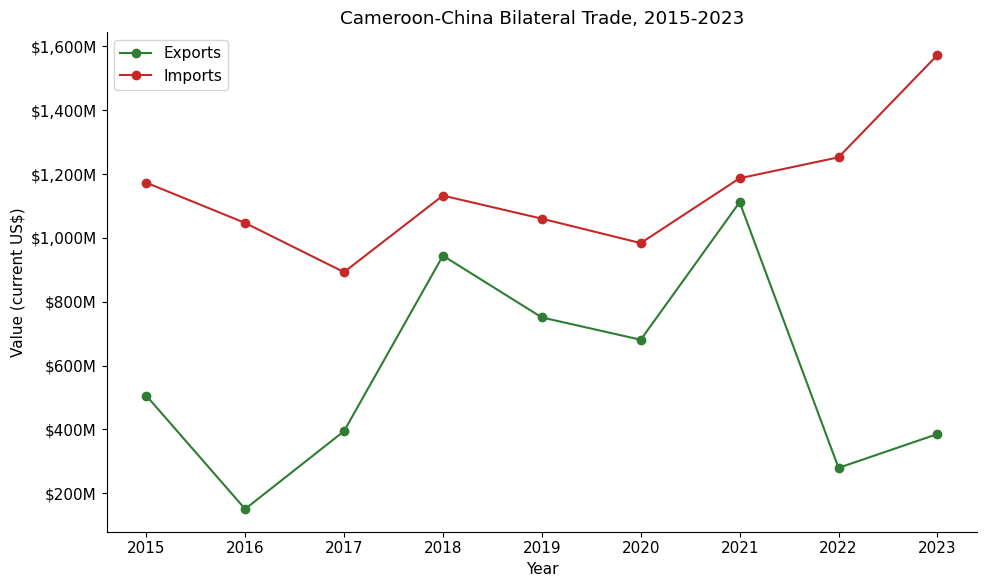

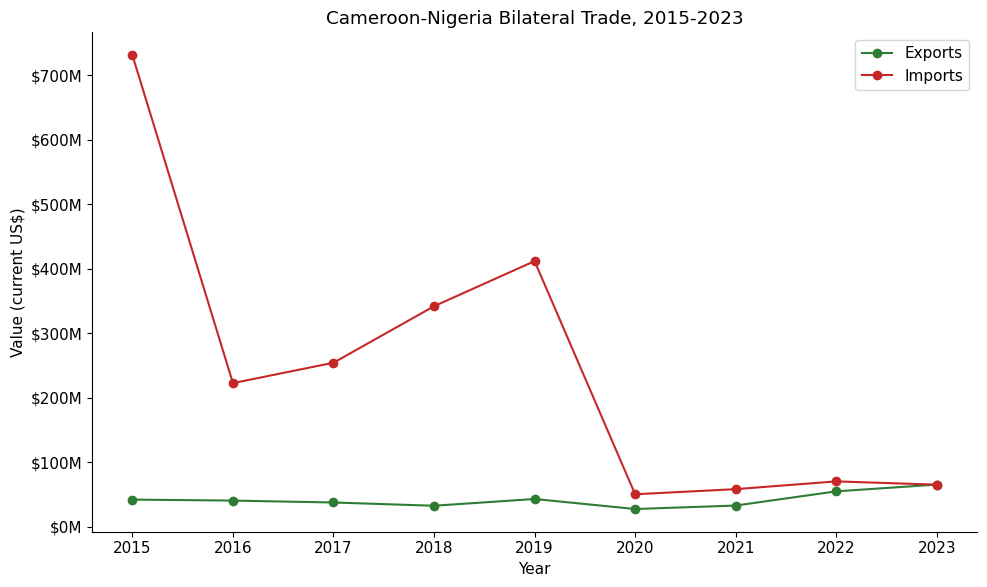

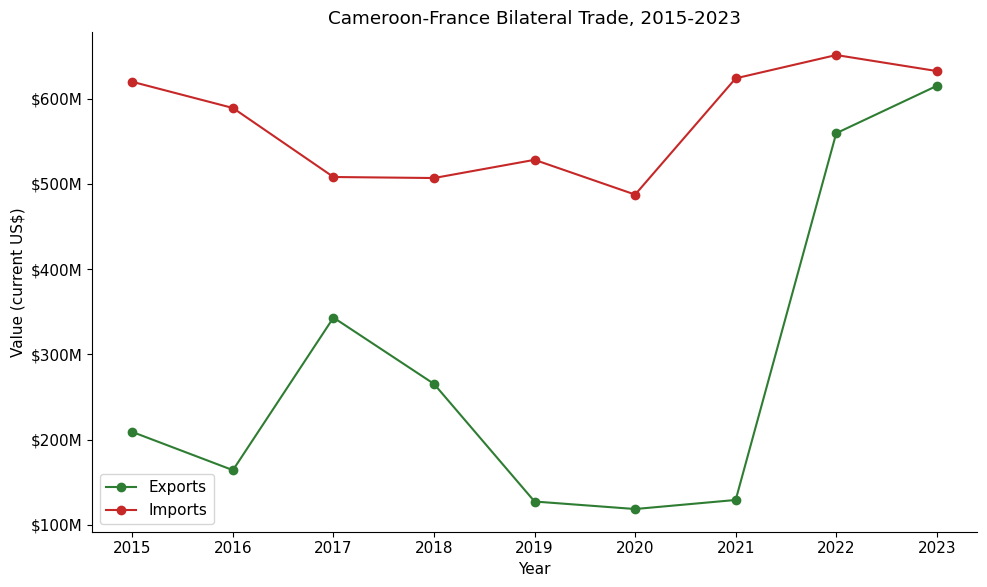

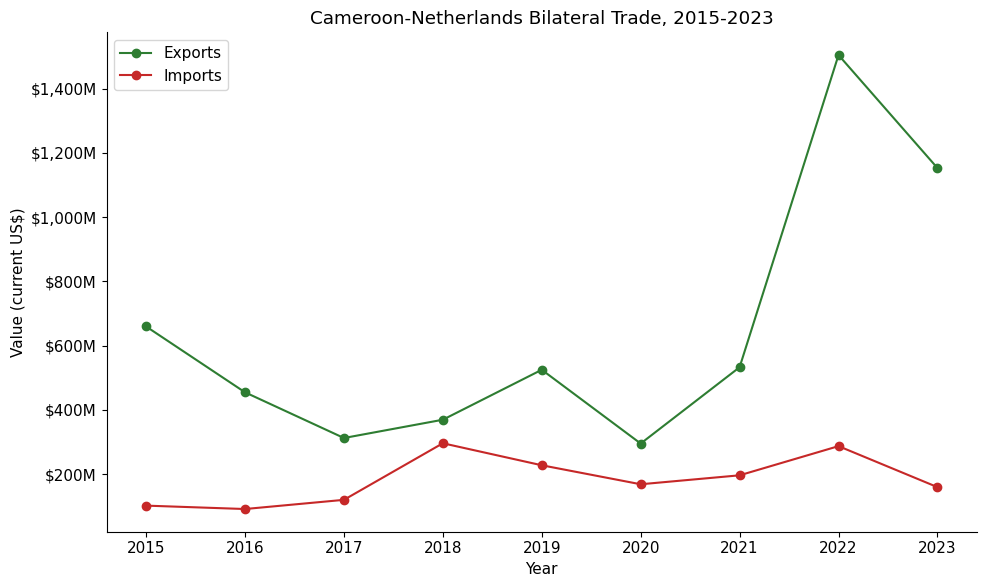

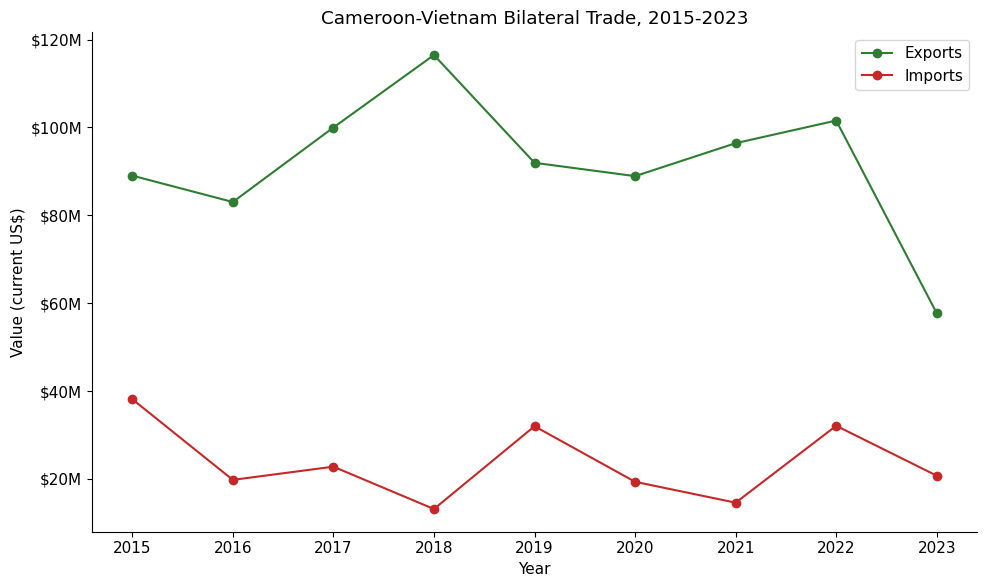

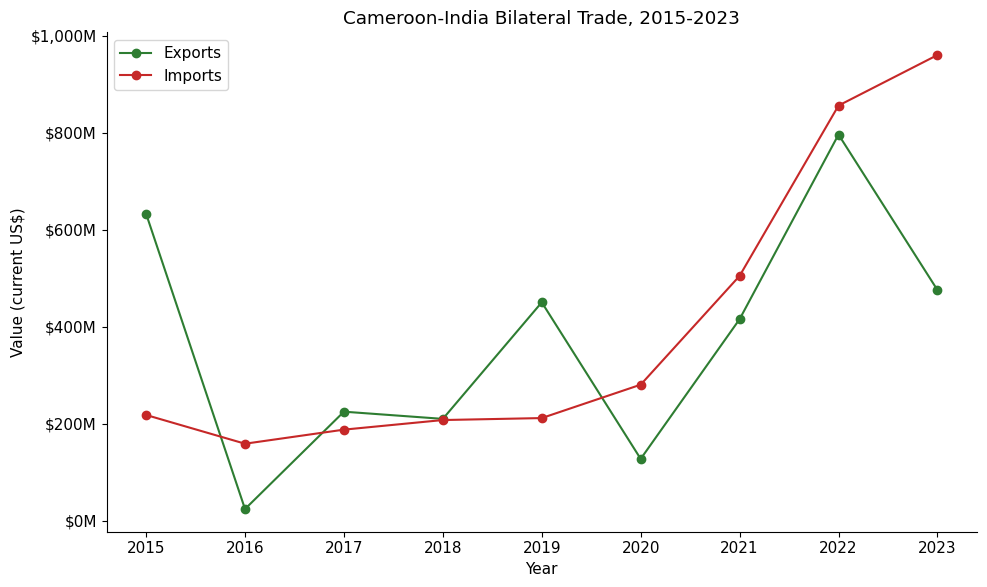

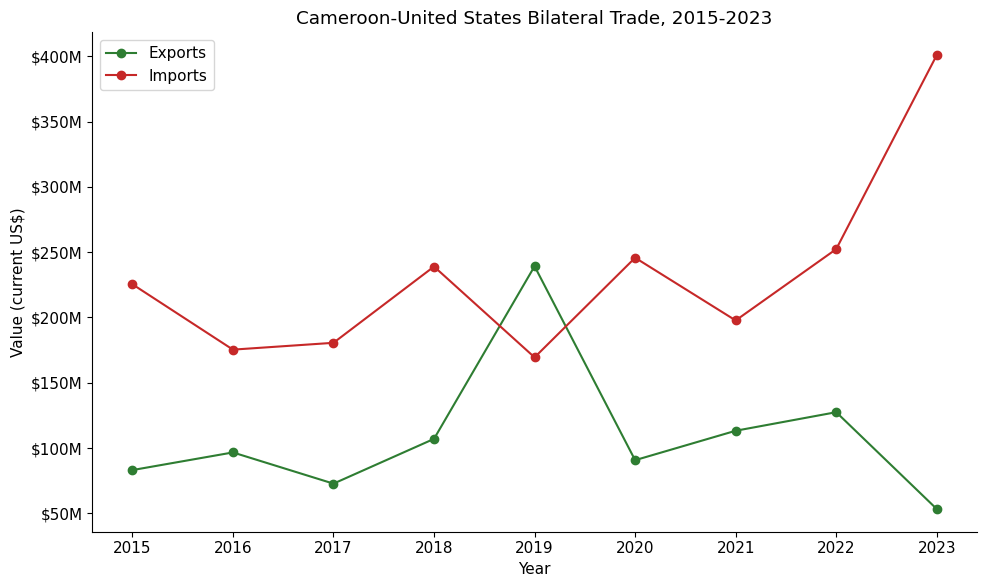

In [31]:

for i, country in enumerate(PRIORITY, start=10):
    exp_series = exports_pivot.loc[country] if country in exports_pivot.index else pd.Series(0, index=years)
    imp_series = imports_pivot.loc[country] if country in imports_pivot.index else pd.Series(0, index=years)
    exp_series = exp_series.reindex(years, fill_value=0)
    imp_series = imp_series.reindex(years, fill_value=0)

    fig, ax = plt.subplots()
    ax.plot(years, exp_series.values, marker='o', color='#2E7D32', label='Exports')
    ax.plot(years, imp_series.values, marker='o', color='#C62828', label='Imports')
    ax.set_title(f'Cameroon-{country} Bilateral Trade, 2015-2023')
    ax.set_xlabel('Year'); ax.set_ylabel('Value (current US$)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,p: f'${v/1e6:,.0f}M'))
    ax.legend()
    plt.tight_layout()
    fname = f"{i:02d}_{country.lower().replace(' ','_')}_bilateral_trend.png"
    plt.savefig(FIG_DIR + fname, dpi=150)
    plt.show()


## Step 8. Trade Balance by Partner

In [32]:

balance_pivot = exports_pivot.reindex(columns=years, fill_value=0).sub(
    imports_pivot.reindex(columns=years, fill_value=0), fill_value=0)
# Align indices (union of partners that appear in either flow)
all_partners_idx = balance_pivot.index.union(exports_pivot.index).union(imports_pivot.index)
balance_pivot = balance_pivot.reindex(all_partners_idx, fill_value=0)

n_years = len(years)
pct_years_negative = (balance_pivot < 0).sum(axis=1) / n_years
pct_years_positive = (balance_pivot > 0).sum(axis=1) / n_years

partner_balance = pd.DataFrame({
    'total_balance_2015_2023': balance_pivot.sum(axis=1),
    'pct_years_deficit': pct_years_negative * 100,
    'pct_years_surplus': pct_years_positive * 100,
})
partner_balance['classification'] = np.select(
    [partner_balance['pct_years_deficit'] >= 50, partner_balance['pct_years_surplus'] >= 50],
    ['persistent_deficit', 'persistent_surplus'],
    default='mixed')
partner_balance = partner_balance.join(partner_flow[['total_bilateral_trade']])
partner_balance = partner_balance.sort_values('total_balance_2015_2023')
partner_balance.to_csv(TAB_DIR + 'partner_trade_balance.csv')

print("Largest bilateral deficits (2015-2023 cumulative):")
print(partner_balance.head(10).round(1))
print()
print("Largest bilateral surpluses (2015-2023 cumulative):")
print(partner_balance.sort_values('total_balance_2015_2023', ascending=False).head(10).round(1))


Largest bilateral deficits (2015-2023 cumulative):
                    total_balance_2015_2023  pct_years_deficit  \
partner                                                          
China                        -5,096,822,305                100   
France                       -2,615,965,764                100   
Thailand                     -1,955,610,825                100   
Nigeria                      -1,830,133,376                 89   
Togo                         -1,414,913,508                100   
Germany                      -1,332,116,386                100   
Russian Federation           -1,327,542,909                100   
Japan                        -1,227,174,341                100   
United States                -1,102,872,369                 89   
Türkiye                      -1,025,122,738                100   

                    pct_years_surplus      classification  \
partner                                                     
China                             

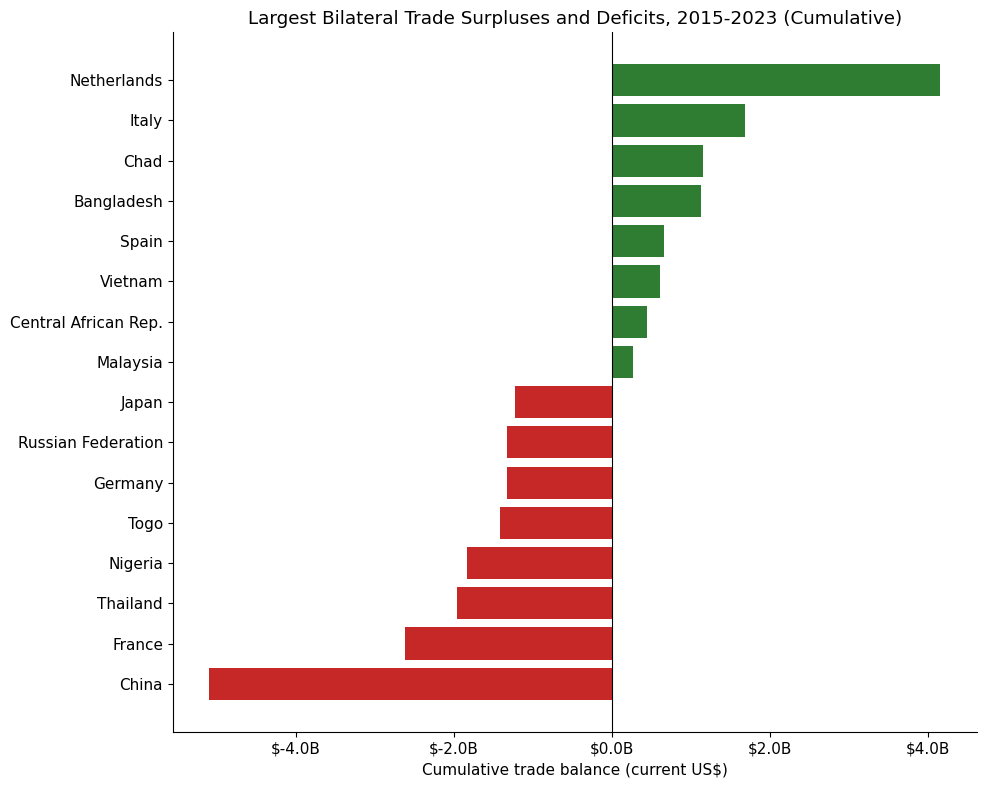

In [33]:

top_deficit = partner_balance.sort_values('total_balance_2015_2023').head(8)
top_surplus = partner_balance.sort_values('total_balance_2015_2023', ascending=False).head(8)
combo = pd.concat([top_surplus, top_deficit]).sort_values('total_balance_2015_2023')

fig, ax = plt.subplots(figsize=(10,8))
colors = ['#C62828' if v < 0 else '#2E7D32' for v in combo['total_balance_2015_2023']]
ax.barh(combo.index, combo['total_balance_2015_2023'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Largest Bilateral Trade Surpluses and Deficits, 2015-2023 (Cumulative)')
ax.set_xlabel('Cumulative trade balance (current US$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
plt.tight_layout()
plt.savefig(FIG_DIR + '08_trade_balance_by_partner.png', dpi=150)
plt.show()


**Definitions used:**
- *Persistent deficit*: Cameroon records a negative bilateral trade balance in at least 5 of the 9 study years (≥50%).
- *Persistent surplus*: Cameroon records a positive bilateral trade balance in at least 5 of the 9 study years (≥50%).


## Step 9. Partner Importance Over Time

In [34]:

total_by_partner_year = exports_pivot.reindex(columns=years, fill_value=0).add(
    imports_pivot.reindex(columns=years, fill_value=0), fill_value=0)
total_by_partner_year = total_by_partner_year.reindex(all_partners_idx, fill_value=0)

trade_2015 = total_by_partner_year[2015]
trade_2023 = total_by_partner_year[2023]

partner_growth = pd.DataFrame({
    'total_trade_2015': trade_2015,
    'total_trade_2023': trade_2023,
})
partner_growth['abs_change'] = partner_growth['total_trade_2023'] - partner_growth['total_trade_2015']
partner_growth['pct_change'] = np.where(partner_growth['total_trade_2015']>0,
    partner_growth['abs_change']/partner_growth['total_trade_2015']*100, np.nan)

n = len(years) - 1
partner_growth['avg_annual_growth_pct'] = np.where(
    partner_growth['total_trade_2015']>0,
    ((partner_growth['total_trade_2023']/partner_growth['total_trade_2015'])**(1/n) - 1) * 100,
    np.nan)

share_2015 = trade_2015 / trade_2015.sum() * 100
share_2023 = trade_2023 / trade_2023.sum() * 100
partner_growth['share_2015_pct'] = share_2015
partner_growth['share_2023_pct'] = share_2023
partner_growth['change_in_share_pp'] = partner_growth['share_2023_pct'] - partner_growth['share_2015_pct']

def classify(row):
    if row['total_trade_2015'] == 0 and row['total_trade_2023'] > 0:
        return 'emerging'
    if pd.isna(row['pct_change']):
        return 'stable'
    if row['pct_change'] > 20:
        return 'growing'
    if row['pct_change'] < -20:
        return 'declining'
    return 'stable'

partner_growth['status'] = partner_growth.apply(classify, axis=1)
partner_growth = partner_growth.sort_values('change_in_share_pp', ascending=False)
partner_growth.to_csv(TAB_DIR + 'partner_growth.csv')

print("Partners whose share of Cameroon's trade increased the most (2015 -> 2023):")
print(partner_growth.head(10)[['total_trade_2015','total_trade_2023','change_in_share_pp','status']].round(2))


Partners whose share of Cameroon's trade increased the most (2015 -> 2023):
                      total_trade_2015  total_trade_2023  change_in_share_pp  \
partner                                                                        
India                      850,627,638     1,435,394,020                   2   
Netherlands                761,942,926     1,312,726,989                   2   
Indonesia                   48,689,815       344,420,282                   2   
France                     828,693,357     1,247,421,612                   1   
Türkiye                    117,874,439       305,070,674                   1   
Belgium                    305,280,605       532,176,408                   1   
United Arab Emirates        72,061,662       217,177,197                   1   
Bangladesh                  73,742,760       213,683,541                   1   
Chad                       113,099,636       260,891,498                   1   
Saudi Arabia                13,956,338      

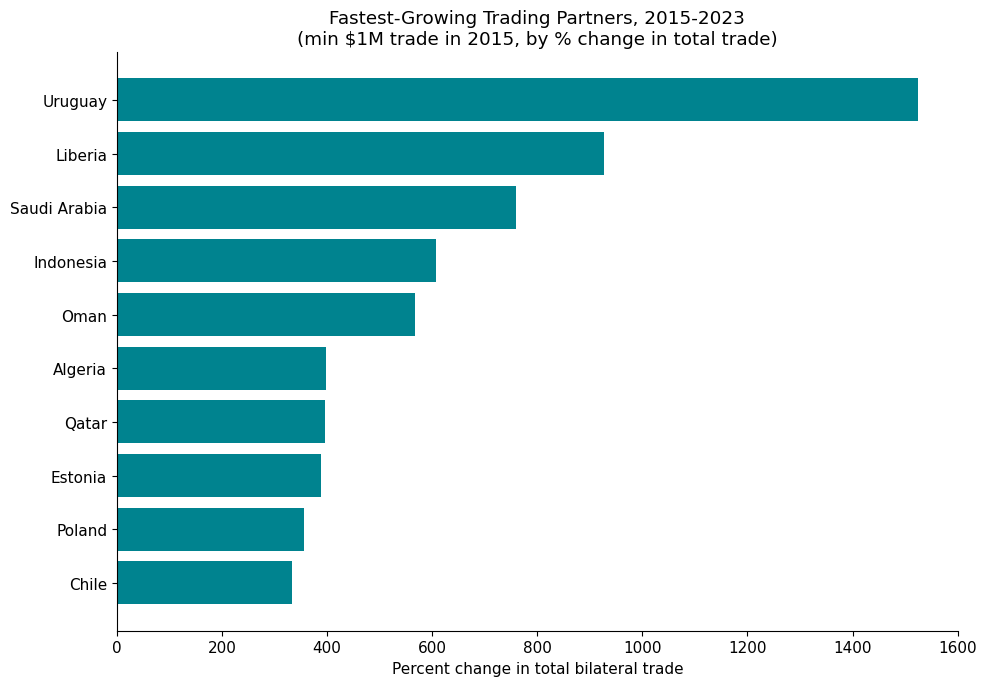

In [35]:

fastest = partner_growth[partner_growth['total_trade_2015'] >= 1e6].sort_values('pct_change', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(fastest.index[::-1], fastest['pct_change'][::-1], color='#00838F')
ax.set_title('Fastest-Growing Trading Partners, 2015-2023\n(min $1M trade in 2015, by % change in total trade)')
ax.set_xlabel('Percent change in total bilateral trade')
plt.tight_layout()
plt.savefig(FIG_DIR + '17_fastest_growing_partners.png', dpi=150)
plt.show()


## Step 10. Trade Concentration

In [36]:

conc_rows = []
for y in years:
    year_totals = total_by_partner_year[y].sort_values(ascending=False)
    total = year_totals.sum()
    top5_share = year_totals.head(5).sum() / total * 100
    top10_share = year_totals.head(10).sum() / total * 100
    shares = year_totals / total
    hhi = (shares**2).sum() * 10000  # HHI on a 0-10,000 scale
    conc_rows.append([y, top5_share, top10_share, 100-top10_share, hhi])

concentration = pd.DataFrame(conc_rows, columns=['year','top5_share_pct','top10_share_pct',
    'remaining_partners_share_pct','hhi']).set_index('year')
concentration.to_csv(TAB_DIR + 'trade_concentration.csv')
concentration.round(1)


,top5_share_pct,top10_share_pct,remaining_partners_share_pct,hhi
year,,,,
2015,48,64,36,624
2016,44,62,38,610
2017,43,62,38,564
2018,46,63,37,706
2019,43,64,36,583
2020,41,59,41,601
2021,46,63,37,688
2022,50,64,36,629
2023,49,63,37,619


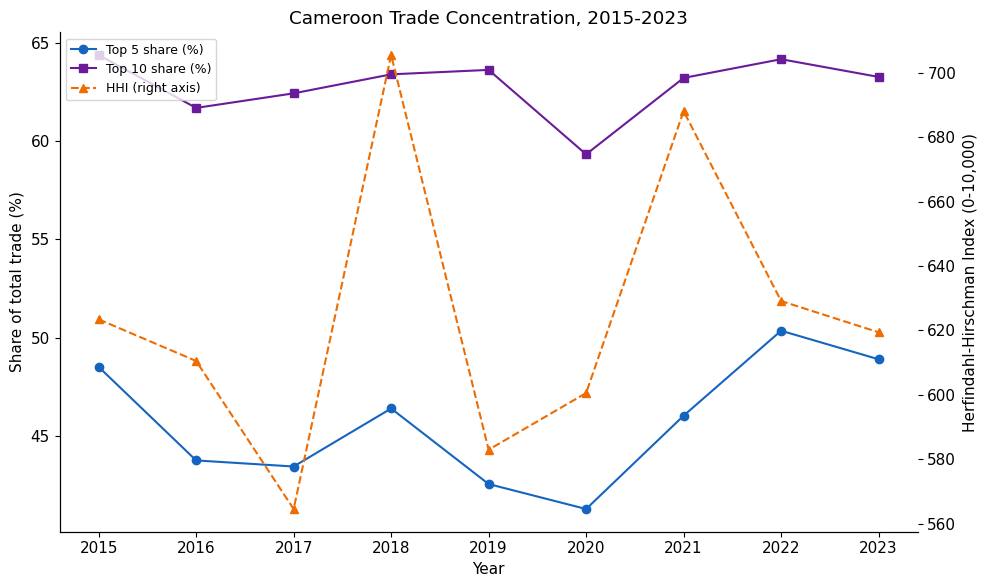

In [37]:

fig, ax1 = plt.subplots()
ax1.plot(concentration.index, concentration['top5_share_pct'], marker='o', label='Top 5 share (%)', color='#1565C0')
ax1.plot(concentration.index, concentration['top10_share_pct'], marker='s', label='Top 10 share (%)', color='#6A1B9A')
ax1.set_xlabel('Year'); ax1.set_ylabel('Share of total trade (%)')
ax1.set_title('Cameroon Trade Concentration, 2015-2023')
ax2 = ax1.twinx()
ax2.plot(concentration.index, concentration['hhi'], marker='^', linestyle='--', color='#EF6C00', label='HHI (right axis)')
ax2.set_ylabel('Herfindahl-Hirschman Index (0-10,000)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR + '18_trade_concentration.png', dpi=150)
plt.show()


In [38]:

hhi_start, hhi_end = concentration['hhi'].iloc[0], concentration['hhi'].iloc[-1]
print(f"HHI in {years[0]}: {hhi_start:.0f}")
print(f"HHI in {years[-1]}: {hhi_end:.0f}")
direction = 'increased (more concentrated)' if hhi_end > hhi_start else 'decreased (more diversified)'
print(f"Trade concentration {direction} over the study period.")
print("Reference: HHI < 1,500 = unconcentrated; 1,500-2,500 = moderate concentration; > 2,500 = high concentration.")


HHI in 2015: 623
HHI in 2023: 619
Trade concentration decreased (more diversified) over the study period.
Reference: HHI < 1,500 = unconcentrated; 1,500-2,500 = moderate concentration; > 2,500 = high concentration.


**Implications of trade concentration:**
- *Trade resilience*: high concentration means shocks to one or two partner economies (demand collapse, policy change, exchange-rate shifts) have outsized effects on Cameroon's total trade.
- *Export diversification*: a small number of export destinations increases vulnerability to demand or price swings in those specific markets, particularly for commodity exports.
- *Import dependence*: concentrated import sourcing raises exposure to supply disruptions and price shocks from a handful of countries.
- *Economic risk*: concentration is not inherently negative (it can reflect efficient specialization), but combined with a persistent trade deficit it compounds external vulnerability.


## Step 11. Priority Partner Comparison

In [39]:

priority_final = bilateral_summary.copy()
priority_final = priority_final.join(partner_growth[['pct_change','avg_annual_growth_pct','status']])
priority_final = priority_final.rename(columns={'pct_change':'total_trade_growth_pct_2015_2023'})
priority_final['rank_by_total_trade'] = priority_final['total_bilateral_trade'].rank(ascending=False).astype(int)
priority_final = priority_final.sort_values('rank_by_total_trade')
priority_final.to_csv(TAB_DIR + 'priority_partner_comparison.csv')
priority_final.round(2)


,exports,imports,total_bilateral_trade,trade_balance,share_of_total_trade_pct,total_trade_growth_pct_2015_2023,avg_annual_growth_pct,status,rank_by_total_trade
country,,,,,,,,,
China,"5,203,656,959","10,300,479,264","15,504,136,224","-5,096,822,305",17,17,2,stable,1
France,"2,531,021,688","5,146,987,453","7,678,009,141","-2,615,965,764",8,51,5,growing,2
Netherlands,"5,807,682,624","1,650,346,571","7,458,029,195","4,157,336,053",8,72,7,growing,3
India,"3,355,625,487","3,583,750,376","6,939,375,863","-228,124,889",7,69,7,growing,4
United States,"983,847,368","2,086,719,737","3,070,567,105","-1,102,872,369",3,47,5,growing,5
Nigeria,"378,779,330","2,208,912,707","2,587,692,037","-1,830,133,376",3,-83,-20,declining,6
Vietnam,"825,161,574","212,621,187","1,037,782,762","612,540,387",1,-38,-6,declining,7


## Step 12-13. Remaining Visualizations & Tables

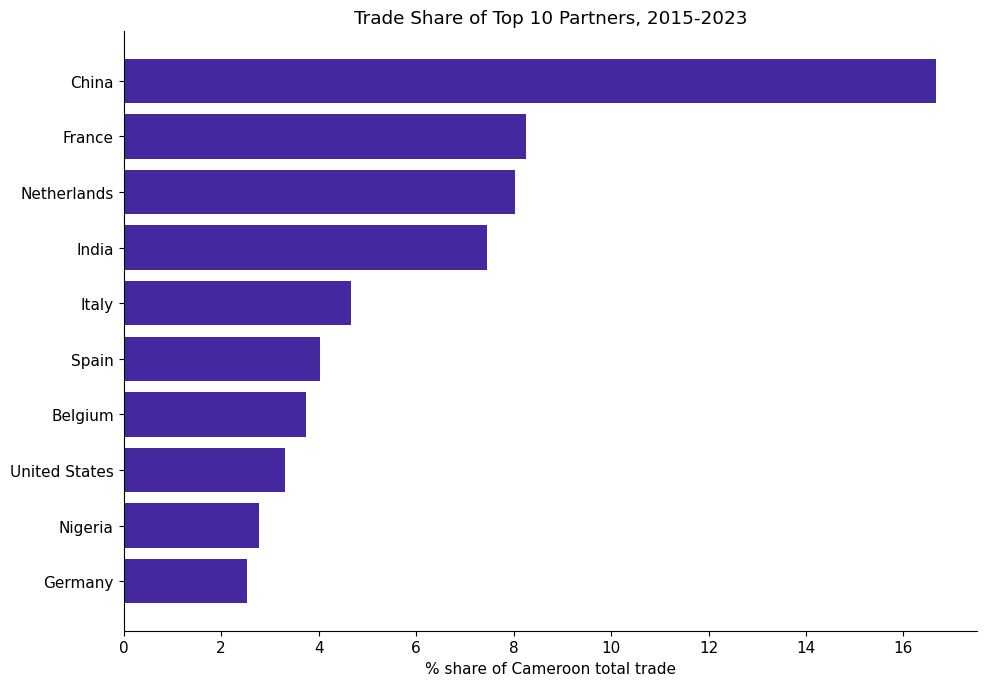

All figures saved to results/figures/, all tables saved to results/tables/
Figures: ['01_total_exports.png', '02_total_imports.png', '03_trade_balance.png', '04_total_trade.png', '05_top10_trading_partners.png', '06_top10_export_destinations.png', '07_top10_import_sources.png', '08_trade_balance_by_partner.png', '09_priority_partner_trade_share.png', '10_china_bilateral_trend.png', '10_trade_share_by_major_partner.png', '11_nigeria_bilateral_trend.png', '12_france_bilateral_trend.png', '13_netherlands_bilateral_trend.png', '14_vietnam_bilateral_trend.png', '15_india_bilateral_trend.png', '16_united_states_bilateral_trend.png', '17_fastest_growing_partners.png', '18_trade_concentration.png']
Tables: ['overall_trade_by_year.csv', 'partner_growth.csv', 'partner_trade_balance.csv', 'priority_country_export_profile.csv', 'priority_country_import_profile.csv', 'priority_partner_bilateral_summary.csv', 'priority_partner_comparison.csv', 'top_export_destinations.csv', 'top_import_sources.csv',

In [40]:

# Trade share by major partner (top 10, pie-free stacked bar as % of total trade)
fig, ax = plt.subplots(figsize=(10,7))
data = ranked_partners.head(10).sort_values('pct_share_total_trade')
ax.barh(data.index, data['pct_share_total_trade'], color='#4527A0')
ax.set_title('Trade Share of Top 10 Partners, 2015-2023')
ax.set_xlabel('% share of Cameroon total trade')
plt.tight_layout()
plt.savefig(FIG_DIR + '10_trade_share_by_major_partner.png', dpi=150)
plt.show()

print("All figures saved to results/figures/, all tables saved to results/tables/")
print("Figures:", sorted(os.listdir(FIG_DIR)))
print("Tables:", sorted(os.listdir(TAB_DIR)))


## Step 14. Key Findings

In [41]:

print("=== DIRECT FINDINGS (from data) ===\n")

print("1. Most important trading partners (by total bilateral trade, 2015-2023):")
print(ranked_partners.head(5)[['total_bilateral_trade','pct_share_total_trade']].round(1))
print()

print("2. Largest export destinations:")
print(top_export_dest.head(5).round(1))
print()

print("3. Largest import sources:")
print(top_import_src.head(5).round(1))
print()

print("4. Relationships that grew strongest (min $1M trade in 2015):")
print(fastest.head(5).round(1))
print()

print("5. Relationships that weakened most (min $1M trade in 2015):")
weakest = partner_growth[partner_growth['total_trade_2015'] >= 1e6].sort_values('pct_change').head(5)
print(weakest[['total_trade_2015','total_trade_2023','pct_change']].round(1))
print()

print("6. Persistent trade deficits (>=50% of years negative):")
print(partner_balance[partner_balance['classification']=='persistent_deficit'].sort_values('total_balance_2015_2023').head(8)[['total_balance_2015_2023']].round(1))
print()

print("7. Persistent trade surpluses (>=50% of years positive):")
print(partner_balance[partner_balance['classification']=='persistent_surplus'].sort_values('total_balance_2015_2023', ascending=False).head(8)[['total_balance_2015_2023']].round(1))
print()

print(f"8. Trade concentration (HHI): {hhi_start:.0f} in 2015 -> {hhi_end:.0f} in 2023 ({direction}).")
print(f"   Top 5 partners' combined share: {top5['pct_share_total_trade'].sum():.1f}% of total trade.")
print()

print("9. Emerging partners (zero trade in 2015, positive by 2023):")
print(emerging_exports.head(5)[['export_2023']].round(1) if len(emerging_exports)>0 else 'None material')


=== DIRECT FINDINGS (from data) ===

1. Most important trading partners (by total bilateral trade, 2015-2023):
trade_flow   total_bilateral_trade  pct_share_total_trade
partner                                                  
China               15,504,136,224                     17
France               7,678,009,141                      8
Netherlands          7,458,029,195                      8
India                6,939,375,863                      8
Italy                4,335,483,929                      5

2. Largest export destinations:
trade_flow   total_exports  pct_share_exports
partner                                      
Netherlands  5,807,682,624                 16
China        5,203,656,959                 15
India        3,355,625,487                 10
Italy        3,009,489,371                  8
France       2,531,021,688                  7

3. Largest import sources:
trade_flow     total_imports  pct_share_imports
partner                                        
Chin

**Interpretation (separated from the direct findings above):**

- Cameroon's trade is concentrated among a small set of partners, which is typical for a
  commodity-exporting economy but leaves total trade sensitive to conditions in those specific
  markets.
- A persistent deficit with the partners that supply capital goods, fuel, and manufactured
  imports is consistent with Cameroon's status as a net importer of manufactured products.
- Growth among the fastest-rising partners should be read cautiously where the 2015 base value
  is small — a low base year mechanically produces a large percentage change even for modest
  absolute increases (the `avg_annual_growth_pct` and absolute-value columns in the saved tables
  should be read alongside the percentage-change figures for this reason).


## Step 15. Business and Policy Interpretation

- **Trade diversification**: The concentration analysis (Step 10) shows how reliant Cameroon's
  trade is on its top partners; a rising HHI or top-5 share signals increasing dependence, which
  most economies try to manage through active market diversification.
- **Import dependence**: The import-source rankings (Step 6) show which countries account for the
  largest shares of Cameroon's imports; heavy reliance on a few suppliers for critical goods
  (fuel, machinery, food staples) is a supply-security consideration for policymakers.
- **Export-market concentration**: The export-destination rankings (Step 5) show whether
  Cameroon's export earnings depend on a narrow set of buyers, which affects exposure to demand
  or price shocks in those specific markets.
- **Bilateral trade risks**: Partners with large, persistent deficits (Step 8) represent
  relationships where Cameroon is a structural net importer; partners with large surpluses
  represent relationships where Cameroon is a structural net exporter. Both carry different types
  of risk (import-cost exposure vs. export-demand exposure).
- **Emerging trading relationships**: Partners newly appearing or growing rapidly from a low base
  (Step 9) merit monitoring as potential future markets or supply sources, while acknowledging the
  small-base caveat noted above.
- **Potential areas for trade-policy attention**: Relationships combining (a) a large trade share,
  (b) a persistent deficit, and (c) low or negative growth are natural candidates for trade-policy
  or trade-facilitation attention, since they combine size, imbalance, and stagnation.
- **Potential areas for further agricultural export research**: This phase deliberately does not
  analyze individual products; any agricultural-specific conclusions require the product-level
  data described in Step 16.


## Step 16. Limitations

- **Time period**: The dataset actually covers **2015-2023** (9 years), not 2015-2025 as
  originally scoped, because 2024-2025 data was not available from UN Comtrade in this extract.
  All "over the period" statements in this notebook refer to 2015-2023.
- **Aggregate product data**: The dataset uses `cmdCode = TOTAL`, so no individual agricultural
  product or product category can be identified. All findings describe total merchandise trade
  only.
- **Trade-value basis**: Values are `primaryValue` in current (nominal) US dollars; no adjustment
  for inflation or exchange-rate movements has been applied, so real (inflation-adjusted) trends
  may differ from the nominal trends shown here.
- **Missing observations**: A small number of rows had missing `primaryValue` and were dropped
  (see Step 2); this has a negligible effect on totals given the size of the dataset.
- **Reporting differences**: UN Comtrade partner-reported ("mirror") data can differ from
  Cameroon-reported data for the same trade flow due to valuation conventions (FOB vs CIF),
  timing, and re-export attribution; this analysis uses Cameroon's own reported values only.
- **No causal inference**: Growth, decline, and concentration measures are descriptive. They do
  not establish why a relationship grew or shrank (e.g., policy change vs. commodity price cycle
  vs. one-off shipment).
- **No product-level opportunity identification**: This dataset cannot identify specific
  agricultural export opportunities, since it contains no product breakdown. Phase 2 will require
  product-level (HS chapter or heading) bilateral trade data to extend this analysis to specific
  agricultural commodities.


## Step 17. Executive Summary

**Objective.** This project analyzes Cameroon's bilateral merchandise trade relationships to
identify its most important trading partners, understand the direction and balance of those
relationships, and assess how concentrated Cameroon's trade is among a small set of countries.

**Dataset.** UN Comtrade bilateral trade data for Cameroon (reporter), all partners, both import
and export flows, total product aggregation, covering 2015-2023 (2024-2025 not yet available at
extraction time).

**Methodology.** The raw Comtrade extract was cleaned and validated (reporter, partner2, flow, and
duplicate checks), then aggregated by year, partner, and trade flow to compute exports, imports,
total bilateral trade, and trade balances at both the country and total-trade level. Partner
importance was measured by total bilateral trade value and share of Cameroon's total trade;
change in importance was measured by percentage change and change in trade share between 2015 and
2023; and overall concentration was measured with top-5/top-10 trade shares and a
Herfindahl-Hirschman Index.


In [42]:

print("Major trading partners (top 5 by total bilateral trade, 2015-2023):")
print((top5['pct_share_total_trade'].round(1).astype(str) + '%').to_string())
print()
print("Major export destinations (top 3):", list(top_export_dest.head(3).index))
print("Major import sources (top 3):", list(top_import_src.head(3).index))
print()
print("Countries with persistent trade deficits (top 3 by size):")
print(list(partner_balance[partner_balance['classification']=='persistent_deficit'].sort_values('total_balance_2015_2023').head(3).index))
print("Countries with persistent trade surpluses (top 3 by size):")
print(list(partner_balance[partner_balance['classification']=='persistent_surplus'].sort_values('total_balance_2015_2023', ascending=False).head(3).index))
print()
print(f"Trade concentration (HHI): {hhi_start:.0f} ({years[0]}) -> {hhi_end:.0f} ({years[-1]}), {direction}.")
print(f"Overall trade balance moved from {overall.loc[2015,'trade_balance']:,.0f} USD in 2015 to {overall.loc[2023,'trade_balance']:,.0f} USD in 2023.")


Major trading partners (top 5 by total bilateral trade, 2015-2023):
partner
China          16.7%
France          8.3%
Netherlands     8.0%
India           7.5%
Italy           4.7%

Major export destinations (top 3): ['Netherlands', 'China', 'India']
Major import sources (top 3): ['China', 'France', 'India']

Countries with persistent trade deficits (top 3 by size):
['China', 'France', 'Thailand']
Countries with persistent trade surpluses (top 3 by size):
['Netherlands', 'Italy', 'Chad']

Trade concentration (HHI): 623 (2015) -> 619 (2023), decreased (more diversified).
Overall trade balance moved from -1,984,171,530 USD in 2015 to -3,329,363,153 USD in 2023.


**Key business and policy implications:** Cameroon's trade is concentrated among a
relatively small set of partners and runs a persistent overall trade deficit driven mainly by a
handful of import relationships. Diversifying export markets, monitoring fast-growing partners for
emerging opportunities, and tracking the countries responsible for the largest and most persistent
bilateral deficits are the most actionable, data-supported priorities coming out of this phase.
Product-level analysis (Phase 2) is required before drawing any agricultural-market-specific
conclusions.
